<a href="https://colab.research.google.com/github/Raju-mia-RK/Raju/blob/colab_work/ModelComparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df=pd.read_csv('/content/drive/MyDrive/datasets/heart.csv')

In [4]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [10]:
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,recall_score,f1_score,accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [20]:
df=pd.get_dummies(df,columns=['RestingECG'])

In [22]:
df=pd.get_dummies(df,columns=['ExerciseAngina'])

In [23]:
df=pd.get_dummies(df,columns=['ST_Slope'])

In [24]:
df=pd.get_dummies(df,columns=['ChestPainType'])

KeyError: "None of [Index(['ChestPainType'], dtype='object')] are in the [columns]"

In [21]:
df=pd.get_dummies(df,columns=['ChestPainType'])

KeyError: "None of [Index(['ChestPainType'], dtype='object')] are in the [columns]"

In [11]:
encoder=LabelEncoder()
df['Sex']=encoder.fit_transform(df['Sex'])

In [28]:
df['ChestPainType_ASY']=encoder.fit_transform(df['ChestPainType_ASY'])
df['ChestPainType_ATA']=encoder.fit_transform(df['ChestPainType_ATA'])
df['ChestPainType_NAP']=encoder.fit_transform(df['ChestPainType_NAP'])
df['ChestPainType_TA']=encoder.fit_transform(df['ChestPainType_TA'])
df['RestingECG_LVH']=encoder.fit_transform(df['RestingECG_LVH'])
df['RestingECG_Normal']=encoder.fit_transform(df['RestingECG_Normal'])
df['RestingECG_ST']=encoder.fit_transform(df['RestingECG_ST'])
df['ExerciseAngina_N']=encoder.fit_transform(df['ExerciseAngina_N'])
df['ExerciseAngina_Y']=encoder.fit_transform(df['ExerciseAngina_Y'])
df['ST_Slope_Down']=encoder.fit_transform(df['ST_Slope_Down'])
df['ST_Slope_Flat']=encoder.fit_transform(df['ST_Slope_Flat'])
df['ST_Slope_Up']=encoder.fit_transform(df['ST_Slope_Up'])

In [29]:
df.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0.0,0,0,1,0,0,0,1,0,1,0,0,0,1
1,49,0,160,180,0,156,1.0,1,0,0,1,0,0,1,0,1,0,0,1,0
2,37,1,130,283,0,98,0.0,0,0,1,0,0,0,0,1,1,0,0,0,1
3,48,0,138,214,0,108,1.5,1,1,0,0,0,0,1,0,0,1,0,1,0
4,54,1,150,195,0,122,0.0,0,0,0,1,0,0,1,0,1,0,0,0,1


In [31]:
x=df.drop('HeartDisease',axis=1)
y=df['HeartDisease']
y.value_counts()

,count
HeartDisease,
1,508
0,410


In [32]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [33]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

KNN

In [37]:
accuries=[]
for i in range(1,25):
  knn=KNeighborsClassifier(n_neighbors=i)
  knn.fit(x_train,y_train)
  print(accuracy_score(y_test,knn.predict(x_test)),accuracy_score(y_train,knn.predict(x_train)),i)
  accuries.append(accuracy_score(y_test,knn.predict(x_test)))
best_k=accuries.index(max(accuries))+1


0.782608695652174 1.0 1
0.7391304347826086 0.9141689373297003 2
0.8369565217391305 0.9128065395095368 3
0.8315217391304348 0.8991825613079019 4
0.8695652173913043 0.8828337874659401 5
0.8586956521739131 0.8841961852861036 6
0.875 0.8787465940054496 7
0.8586956521739131 0.8787465940054496 8
0.8858695652173914 0.8746594005449592 9
0.8641304347826086 0.8678474114441417 10
0.8804347826086957 0.8692098092643051 11
0.875 0.8651226158038147 12
0.8858695652173914 0.8651226158038147 13
0.875 0.8610354223433242 14
0.8695652173913043 0.8678474114441417 15
0.8695652173913043 0.8651226158038147 16
0.875 0.8678474114441417 17
0.875 0.8637602179836512 18
0.8913043478260869 0.8637602179836512 19
0.8858695652173914 0.8678474114441417 20
0.8913043478260869 0.8610354223433242 21
0.8804347826086957 0.8623978201634878 22
0.8913043478260869 0.8678474114441417 23
0.8695652173913043 0.8637602179836512 24


In [72]:
knn_model=KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(x_train,y_train)
knn_model.score(x_test,y_test)
knn_accuracy=accuracy_score(y_test,knn_model.predict(x_test))
print(f"Accuracy Score: {knn_accuracy}")
print(f"recall Score: {recall_score(y_test,knn_model.predict(x_test))}")
print(f"f1 Score: {f1_score(y_test,knn_model.predict(x_test))}")

Accuracy Score: 0.8913043478260869
recall Score: 0.8785046728971962
f1 Score: 0.9038461538461539


In [44]:
cm=confusion_matrix(y_test,knn_model.predict(x_test))

<Axes: >

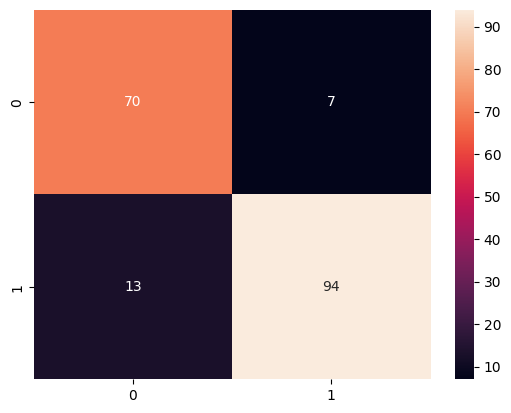

In [45]:
sns.heatmap(cm,annot=True)

Decision Tree

In [48]:
accuracy_dt=[]
for i in range(1,20):
  dt=DecisionTreeClassifier(max_depth=i)
  dt.fit(x_train,y_train)
  print(accuracy_score(y_test,dt.predict(x_test)),accuracy_score(y_train,dt.predict(x_train)),i)
  accuracy_dt.append(accuracy_score(y_test,dt.predict(x_test)))
max_de=accuracy_dt.index(max(accuracy_dt))+1


0.7989130434782609 0.8174386920980926 1
0.842391304347826 0.8337874659400545 2
0.8478260869565217 0.8569482288828338 3
0.8695652173913043 0.8773841961852861 4
0.8695652173913043 0.8978201634877384 5
0.8315217391304348 0.9100817438692098 6
0.8097826086956522 0.9305177111716622 7
0.8043478260869565 0.952316076294278 8
0.8152173913043478 0.9591280653950953 9
0.7989130434782609 0.9782016348773842 10
0.8152173913043478 0.9836512261580381 11
0.8152173913043478 0.9931880108991825 12
0.8097826086956522 0.9986376021798365 13
0.7989130434782609 0.9986376021798365 14
0.8043478260869565 1.0 15
0.7934782608695652 1.0 16
0.8206521739130435 1.0 17
0.8152173913043478 1.0 18
0.7934782608695652 1.0 19


In [49]:
max_de

4

In [74]:
dt_model=DecisionTreeClassifier(max_depth=max_de)
dt_model.fit(x_train,y_train)
dt_accuracy=accuracy_score(y_test,dt_model.predict(x_test))
print(f"Accuracy Score: {dt_accuracy}")
print(f"recall Score: {recall_score(y_test,dt_model.predict(x_test))}")
print(f"f1 Score: {f1_score(y_test,dt_model.predict(x_test))}")

Accuracy Score: 0.8695652173913043
recall Score: 0.8785046728971962
f1 Score: 0.8867924528301887


<Axes: >

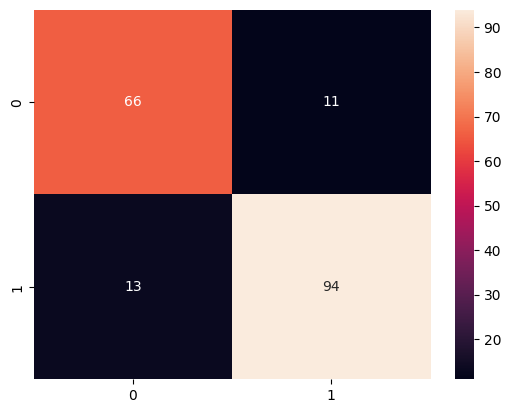

In [52]:
cm_dt=confusion_matrix(y_test,dt_model.predict(x_test))
sns.heatmap(cm_dt,annot=True)

Random Forest

In [58]:
random_model=RandomForestClassifier(
    n_estimators=100,
    min_samples_leaf=20,
    min_samples_split=20,
    n_jobs=1
)

In [59]:
random_model.fit(x_train,y_train)

RandomForestClassifier(min_samples_leaf=20, min_samples_split=20, n_jobs=1)

In [61]:
random_model.score(x_test,y_test)

0.8532608695652174

In [75]:
random_accuracy=accuracy_score(y_test,random_model.predict(x_test))
print(f"Accuracy Score: {random_accuracy}")
print(f"recall Score: {recall_score(y_test,random_model.predict(x_test))}")
print(f"f1 Score: {f1_score(y_test,random_model.predict(x_test))}")

Accuracy Score: 0.8532608695652174
recall Score: 0.8598130841121495
f1 Score: 0.8720379146919431


<Axes: >

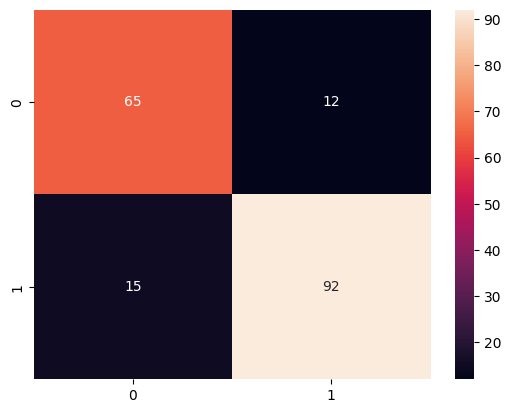

In [62]:
cm_random=confusion_matrix(y_test,random_model.predict(x_test))
sns.heatmap(cm_random,annot=True)

In [65]:
Feature_importan_random=pd.DataFrame({
    'Feature':x.columns,
    'Importance':random_model.feature_importances_
}).sort_values('Importance',ascending=False)
print(Feature_importan_random.to_string(index=False))

          Feature  Importance
      ST_Slope_Up    0.222951
    ST_Slope_Flat    0.179280
 ExerciseAngina_Y    0.118875
          Oldpeak    0.103180
ChestPainType_ASY    0.089584
 ExerciseAngina_N    0.078699
            MaxHR    0.053641
      Cholesterol    0.047368
              Age    0.028323
ChestPainType_ATA    0.021172
              Sex    0.019531
        FastingBS    0.012725
        RestingBP    0.009188
ChestPainType_NAP    0.005984
    ST_Slope_Down    0.004215
RestingECG_Normal    0.002523
   RestingECG_LVH    0.002475
    RestingECG_ST    0.000287
 ChestPainType_TA    0.000000


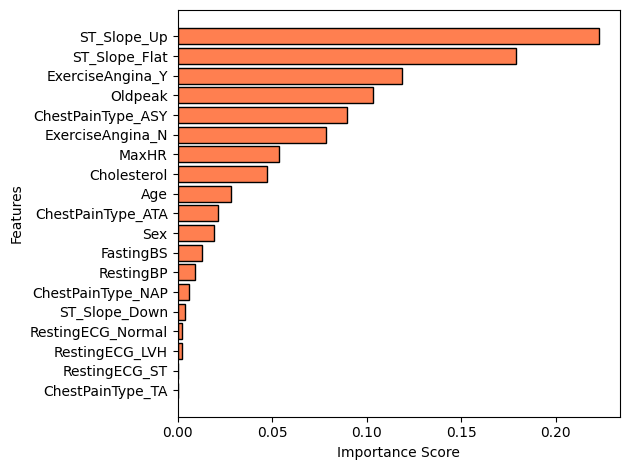

In [68]:
plt.barh(Feature_importan_random['Feature'],Feature_importan_random['Importance'],color='coral',edgecolor='black')
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.ylabel('Features')
plt.tight_layout()

In [82]:
comparison = pd.DataFrame({
    'Model': ['knn_model', 'dt_model', 'random_model'],
    'Accuracy': [knn_accuracy, dt_accuracy, random_accuracy],
    'Accuracy %': [f"{knn_accuracy*100:.2f}%", f"{dt_accuracy*100:.2f}%", f"{random_accuracy*100:.2f}%"]
})
comparison = comparison.sort_values('Accuracy', ascending=False)

Text(0.5, 1.0, 'Model Comparison')

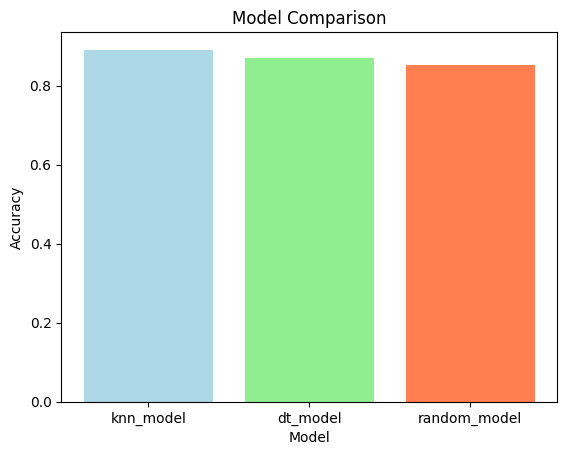

In [81]:
plt.bar(comparison['Model'], comparison['Accuracy'], color=['lightblue', 'lightgreen', 'coral'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Comparison')

In [85]:
best_acc = comparison.iloc[0]['Model']
print(f"Best model is: {best_acc}")

Best model is: knn_model
